In [24]:
import polars as pl

df = (
    pl.scan_parquet("//allen/programs/mindscope/workgroups/dynamicrouting/ben/spike_counts.parquet")
    # .tail(1_000)
    .with_columns(
        session_id=pl.col('unit_id').str.split('_').list.slice(0, 2).list.join('_'),
    )
    # get spike-count / time correlation values ------------------------ #
    .join(
        other=pl.scan_parquet("//allen/programs/mindscope/workgroups/dynamicrouting/ben/corr_values.parquet"),
        on='unit_id',
        how='inner',
    )
    # get annotations -------------------------------------------------- #
    .join(
        other=(
            pl.scan_parquet("//allen/programs/mindscope/workgroups/dynamicrouting/ben/unit_drift.parquet")
            .select('unit_id', 'drift_rating')
            .filter(
                pl.col('drift_rating') != 5,
            )
        ),
        on='unit_id',
        how='left',
    )
    # get unit metrics from sorting ------------------------------------ #
    .join(
        other=(
            pl.scan_parquet("s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.261/consolidated/units.parquet")
            .select('unit_id', 'presence_ratio')
        ),
        on='unit_id',
        how='left',
    )
    # get anova metrics ------------------------------------------------ #
    .join(
        other=(
            pl.scan_parquet("//allen/programs/mindscope/workgroups/dynamicrouting/ben/anova.parquet")
            .select('unit_id', 'anova_baseline_F_block', 'anova_baseline_F_context', 'anova_response_F_context')
        ),
        on='unit_id',
        how='left',
    )
    # get ancova metrics ------------------------------------------------ #
    .join(
        other=(
            pl.scan_parquet("//allen/programs/mindscope/workgroups/dynamicrouting/ben/ancova.parquet")
        ),
        on='unit_id',
        how='left',
    )
    # get trial metadata ----------------------------------------------- #
    # .join(
    #     other=(
    #         pl.scan_parquet("s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.261/consolidated/trials.parquet")
    #         .select('session_id', 'trial_index', 'block_index', 'context_name', 'start_time')
    #     ),
    #     on=['session_id', 'trial_index',],
    #     how='inner',
    # )
    # aggregate spike counts by block ---------------------------------- #
    # .group_by(gb_cols := ['unit_id', 'block_index', 'context_name'])
    # .agg(
    #     pl.all().exclude('baseline', 'response'),
    #     pl.col('baseline').median(),
    #     pl.col('response').median(),
    # )
    # .explode(pl.all().exclude(*gb_cols, 'baseline', 'response'))
    # discard trial info ----------------------------------------------- #
    # .drop('trial_index')
    # .group_by('unit_id', 'block_index').agg(pl.all()).explode(pl.all().exclude('unit_id', 'block_index'))
    # ------------------------------------------------------------------ #
    .collect(streaming=False)
)
df

trial_index,unit_id,baseline,response,session_id,vis_baseline_r2,aud_baseline_r2,vis_response_r2,aud_response_r2,drift_rating,presence_ratio,anova_baseline_F_block,anova_baseline_F_context,anova_response_F_context,ancova_t_context,ancova_coef_context,ancova_p_context,ancova_t_time,ancova_coef_time,ancova_p_time
i64,str,i64,i64,str,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""626791_2022-08-16_A-22""",0,0,"""626791_2022-08-16""",0.058367,0.020901,0.17696,0.078642,null,1.0,7.013759,0.111029,0.712652,3.525,0.0434,0.0,5.87,0.0535,0.0
1,"""626791_2022-08-16_A-22""",0,1,"""626791_2022-08-16""",0.058367,0.020901,0.17696,0.078642,null,1.0,7.013759,0.111029,0.712652,3.525,0.0434,0.0,5.87,0.0535,0.0
2,"""626791_2022-08-16_A-22""",0,1,"""626791_2022-08-16""",0.058367,0.020901,0.17696,0.078642,null,1.0,7.013759,0.111029,0.712652,3.525,0.0434,0.0,5.87,0.0535,0.0
3,"""626791_2022-08-16_A-22""",0,0,"""626791_2022-08-16""",0.058367,0.020901,0.17696,0.078642,null,1.0,7.013759,0.111029,0.712652,3.525,0.0434,0.0,5.87,0.0535,0.0
4,"""626791_2022-08-16_A-22""",2,0,"""626791_2022-08-16""",0.058367,0.020901,0.17696,0.078642,null,1.0,7.013759,0.111029,0.712652,3.525,0.0434,0.0,5.87,0.0535,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
533,"""742903_2024-10-22_D-180""",0,0,"""742903_2024-10-22""",0.012766,0.000296,0.057461,0.091052,0,1.0,1.31944,0.000497,0.038316,1.837,0.2498,0.132669,4.026,0.3542,0.0
534,"""742903_2024-10-22_D-180""",0,0,"""742903_2024-10-22""",0.012766,0.000296,0.057461,0.091052,0,1.0,1.31944,0.000497,0.038316,1.837,0.2498,0.132669,4.026,0.3542,0.0
535,"""742903_2024-10-22_D-180""",0,0,"""742903_2024-10-22""",0.012766,0.000296,0.057461,0.091052,0,1.0,1.31944,0.000497,0.038316,1.837,0.2498,0.132669,4.026,0.3542,0.0


In [25]:
metrics = (
    df
    .drop('block_index', 'context_name', 'session_id', 'baseline', 'response', 'trial_index', 'start_time', strict=False)
    .unique('unit_id')
    .drop_nulls(pl.all().exclude('drift_rating'))
    .drop_nans()
)
metrics

unit_id,vis_baseline_r2,aud_baseline_r2,vis_response_r2,aud_response_r2,drift_rating,presence_ratio,anova_baseline_F_block,anova_baseline_F_context,anova_response_F_context,ancova_t_context,ancova_coef_context,ancova_p_context,ancova_t_time,ancova_coef_time,ancova_p_time
str,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""664851_2023-11-13_B-142""",0.002416,0.002236,0.013771,0.000475,null,0.9921875,0.635934,2.75638,0.495444,2.669,0.0409,0.01753,2.508,0.0166,0.024329
"""733891_2024-09-19_F-675""",0.011731,0.001271,0.010337,0.007488,null,0.744186,1.820192,0.188522,1.282493,0.556,0.0023,0.696775,1.051,0.0033,0.331448
"""666986_2023-08-15_B-250""",0.000571,0.01011,0.011781,0.002139,null,0.991453,3.445927,0.341373,20.203108,1.207,0.0234,0.307786,1.08,0.0134,0.349049
"""644867_2023-02-22_D-28""",0.015413,0.005059,0.001141,0.043689,null,1.0,7.022212,31.464361,0.678258,0.342,0.0288,0.822488,4.749,0.3381,0.0
"""703333_2024-04-10_F-394""",0.000646,0.000036,0.005892,0.009438,null,0.983607,0.157629,0.157629,0.020114,1.806,0.0182,0.148308,1.713,0.0133,0.122418
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""681532_2023-10-17_A-403""",0.036167,0.05867,0.06743,0.149797,null,1.0,10.221156,10.221156,24.570907,1.953,0.0234,0.163571,7.785,0.0748,0.0
"""714748_2024-06-24_E-6""",0.082131,0.095962,0.173326,0.107701,null,1.0,60.249876,0.195062,0.828183,1.037,0.1169,0.419155,9.218,0.7269,0.0
"""741148_2024-10-15_F-104""",0.151496,0.359132,0.218196,0.487344,null,0.672414,94.670498,398.301989,247.524651,11.338,0.1475,0.0,23.584,0.4723,0.0


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

metrics_to_keep = {'presence_ratio', 'vis_response_r2', 'aud_response_r2', 'ancova_t_time', 'ancova_coef_time'}
metrics_to_drop = set(metrics.columns) - metrics_to_keep - {'unit_id', 'drift_rating'}

annotated = (
    metrics
    .filter(
        pl.col('drift_rating').is_not_null()
    )   
    .drop(metrics_to_drop)
    # z-score remaining metrics
    .with_columns(
        *[(col - col.mean()) / col.std() for col in (pl.col(name) for name in metrics_to_keep)]
    )
)

def get_x_y(df: pl.DataFrame) -> tuple:
    x, y = df.drop('unit_id', 'drift_rating').to_numpy(), df['drift_rating'].to_numpy()
    assert x.shape[0] == y.shape[0]
    return x, y

lda = LinearDiscriminantAnalysis()
unit_id_to_score = {}
for unit_id in annotated['unit_id']:
    train = annotated.filter(pl.col('unit_id') != unit_id)
    test = annotated.filter(pl.col('unit_id') == unit_id)
    lda.fit(*get_x_y(train))
    unit_id_to_score[unit_id] = lda.transform(get_x_y(test)[0]).item()

lda_df = (
    annotated
    .join(pl.DataFrame({'unit_id': unit_id_to_score.keys(), 'lda': unit_id_to_score.values()}), on='unit_id', how='inner')  
)
lda_df.write_parquet("//allen/programs/mindscope/workgroups/dynamicrouting/ben/lda.parquet")
display(lda_df.describe())
display(dict(zip(train.drop('unit_id', 'drift_rating').columns, [float(x) for x in lda.coef_.squeeze()])))

statistic,unit_id,vis_response_r2,aud_response_r2,drift_rating,presence_ratio,ancova_t_time,ancova_coef_time,lda
str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""3996""",3996.0,3996.0,3996.0,3996.0,3996.0,3996.0,3996.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,-2.5250e-16,-1.1647e-16,0.196196,2.1338e-17,2.6672e-18,-8.8907e-19,-0.000045
"""std""",null,1.0,1.0,0.397168,1.0,1.0,1.0,1.412263
"""min""","""626791_2022-08-15_A-491""",-0.693826,-0.705872,0.0,-9.457465,-0.856976,-0.444487,-1.255225
"""25%""",null,-0.6379,-0.646775,0.0,0.269613,-0.612901,-0.388081,-0.939743
"""50%""",null,-0.422657,-0.430202,0.0,0.362281,-0.303255,-0.26589,-0.565682
"""75%""",null,0.172906,0.201633,0.0,0.362281,0.215343,0.028248,0.362666
"""max""","""742903_2024-10-24_F-476""",4.569796,4.834725,1.0,0.362281,10.68381,27.87328,8.766265


{'vis_response_r2': 1.2440484530291558,
 'aud_response_r2': 1.411255659563674,
 'presence_ratio': -1.412751952628877,
 'ancova_t_time': 0.9916312291206728,
 'ancova_coef_time': -0.5727450667648981}

In [43]:
display(dict(zip(train.drop('unit_id', 'drift_rating').columns, [float(x) for x in lda.coef_.squeeze()])))

{'vis_response_r2': 1.2440484530291558,
 'aud_response_r2': 1.411255659563674,
 'presence_ratio': -1.412751952628877,
 'ancova_t_time': 0.9916312291206728,
 'ancova_coef_time': -0.5727450667648981}

In [38]:
dict(zip(train.drop('unit_id', 'drift_rating').columns, lda.coef_.squeeze()))

{'vis_response_r2': np.float64(1.2448649330563908),
 'aud_response_r2': np.float64(1.9582877807507613),
 'presence_ratio': np.float64(-1.434604605368306)}

array([[<Axes: title={'center': 'lda'}>]], dtype=object)

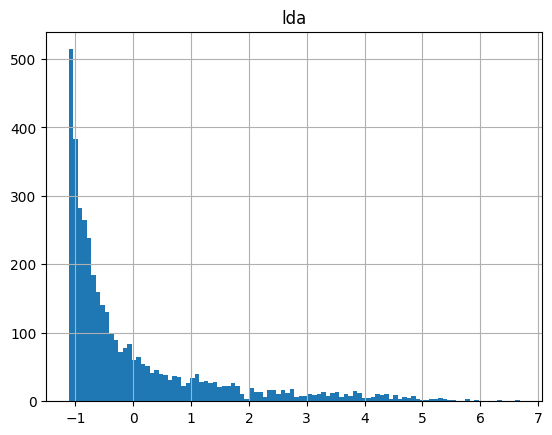

In [105]:
lda_df.drop_nans().drop_nulls().to_pandas().hist('lda', bins=100)

In [40]:
lda.coef_, metrics.columns

(array([[  7.42513725,  10.97882368, -16.09660125]]),
 ['unit_id',
  'vis_baseline_r2',
  'aud_baseline_r2',
  'vis_response_r2',
  'aud_response_r2',
  'drift_rating',
  'presence_ratio'])

In [17]:
(
    pl.read_csv(
        "//allen/programs/mindscope/workgroups/dynamicrouting/ben/fit_ancova.csv"
    )
    .pivot(on='variable', index='unit_id')
    .select(
            'unit_id',
            ancova_t_context=pl.col("t_context").abs(), 
            ancova_coef_context=pl.col("coef_context").abs(), 
            ancova_p_context=pl.col("P_corrected_context"),
            ancova_t_time=pl.col("t_time").abs(), 
            ancova_coef_time=pl.col("coef_time").abs(), 
            ancova_p_time=pl.col("P_corrected_time"),
    )
).write_parquet("//allen/programs/mindscope/workgroups/dynamicrouting/ben/ancova.parquet")

ValueError: array([0, 0, 1, ..., 0, 0, 0], shape=(3738,), dtype=int32) is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

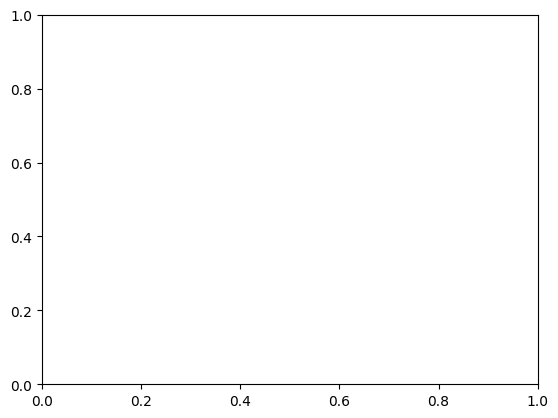

In [44]:
import matplotlib.pyplot as plt

plt.scatter(x2, np.zeros_like(x2), c=y, alpha=.5)

In [24]:
(x[0] * lda.coef_).sum(), x2[0]

(np.float64(-2.71855848050385), array([-0.99841695]))

In [8]:
df.select('aud_baseline_r2', 'vis_response_r2').drop_nans().corr()

aud_baseline_r2,vis_response_r2
f64,f64
1.0,0.727467
0.727467,1.0


In [ ]:
df = (
    pl.read_csv(r"C:\Users\ben.hardcastle\Downloads\fit_anova_baseline.csv")
    .select(
        'unit_id',
        anova_baseline_p_context=pl.col('p_corrected_context'),
        anova_baseline_p_block=pl.col('p_corrected_block'),
        anova_baseline_F_context=pl.col('F_context'),
        anova_baseline_F_block=pl.col('F_block'),
    )
    .join(
        other=(
            pl.read_csv(r"C:\Users\ben.hardcastle\Downloads\fit_anova_response.csv")
            .select(
                'unit_id',
                anova_response_p_context=pl.col('p_corrected_context'),
                anova_response_p_block=pl.col('p_corrected_block'),
                anova_response_p_stim=pl.col('p_corrected_stim'),
                anova_response_F_context=pl.col('F_context'),
                anova_response_F_block=pl.col('F_block'),
                anova_response_F_stim=pl.col('F_stim'),
            )
        ),
        on='unit_id',
        how='inner',
    )
)
df.write_parquet('//allen/programs/mindscope/workgroups/dynamicrouting/ben/anova.parquet')
df

unit_id,anova_baseline_p_context,anova_baseline_p_block,anova_baseline_F_context,anova_baseline_F_block,anova_response_p_context,anova_response_p_block,anova_response_p_stim,anova_response_F_context,anova_response_F_block,anova_response_F_stim
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""626791_2022-08-15_C-113""",1.4776e-19,3.3464e-18,108.564556,24.154684,3.5305e-7,1.7780e-13,3.9239e-25,43.607861,18.861315,25.038658
"""626791_2022-08-15_C-121""",1.0,1.0,2.949936,2.506522,1.0,1.0,1.0,6.508608,0.992763,2.295484
"""626791_2022-08-15_C-122""",1.0,1.8281e-30,6.164226,39.523399,1.0,3.8098e-7,0.007418,9.185624,11.704243,5.709017
"""626791_2022-08-15_C-123""",1.7177e-23,9.0815e-93,131.086774,152.550706,5.5059e-9,5.2669e-54,1.8092e-17,52.692852,77.268901,17.977852
"""626791_2022-08-15_C-124""",0.001596,1.0,25.80729,4.569659,9.3737e-13,9.6009e-12,3.7596e-18,72.29915,16.86434,18.585504
…,…,…,…,…,…,…,…,…,…,…
"""742903_2024-10-24_C-363""",1.0,1.0,9.313972,2.240203,0.000004,0.00027,0.000015,38.672984,8.614845,7.902361
"""742903_2024-10-24_C-180""",1.0,1.0,10.20256,2.25469,7.8948e-41,5.7281e-42,4.9321e-55,243.062048,56.014042,56.888232
"""742903_2024-10-24_C-181""",1.0,1.0,12.298776,2.850432,5.4393e-58,6.1651e-61,5.2601e-76,374.016228,87.161644,85.749202


In [4]:
import functools
from typing import Sequence

import statsmodels.api as sm
from statsmodels.formula.api import ols, glm
import statsmodels.stats.multitest as smm

def fit_anova(list_of_series: Sequence[pl.Series], interval_name: str) -> pl.Series:
        if len(list_of_series) != 3:
            raise ValueError(f"Expected 3 series, got {len(list_of_series)}")
        assert all(s.len() == list_of_series[0].len() for s in list_of_series)
        data = (
            pl.DataFrame(
                {'block': list_of_series[0], 'context': list_of_series[1], 'y': list_of_series[2]}
            )
            .drop_nans()
            .drop_nulls()
        )
        stats = ('PR(>F)', 'F')
        factors = ('context', 'block')
        results = {f'{interval_name}_{stat}_{factor}': None for stat in stats for factor in factors}
        if len(data) <= 1:
            return results
        model = ols('y ~ context + block', data=data.to_pandas()).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        results = {f'{interval_name}_{stat}_{factor}': anova_table.loc[factor, stat] for stat in stats for factor in factors}
        return results
(
    df
    .group_by("unit_id")
    .agg(
        *[
            pl.map_groups(
                exprs=['block_index', 'context_name', interval_name],
                function=functools.partial(fit_anova, interval_name=interval_name),
                return_dtype=pl.Struct,
            ).alias(f"anova_{interval_name}")
            for interval_name in ['baseline', 'response']
        ]
    )
    .unnest('anova_baseline', 'anova_response')
)

PanicException: python function failed: must have at least one row in constraint matrix

In [22]:
pl.read_parquet("//allen/programs/mindscope/workgroups/dynamicrouting/ben/unit_drift.parquet").drop_nulls()['session_id'].value_counts().sort('count')

session_id,count
str,u32
"""713655_2024-08-06""",14
"""713655_2024-08-05""",14
"""715710_2024-07-16""",15
"""733780_2024-09-03""",16
"""733780_2024-08-30""",16
…,…
"""737403_2024-09-25""",27
"""674562_2023-10-02""",28
"""666986_2023-08-17""",28


In [18]:
import polars as pl

lda_all_lf = pl.scan_parquet(
    "//allen/programs/mindscope/workgroups/dynamicrouting/ben/lda_all.parquet"
)
(
    lda_all_lf
    .select('lda')
    .sort('lda')
    .with_columns(
        icdf=1 - (pl.col('lda').cum_count() / pl.col('lda').count()),
    )
).collect().sample(5000).plot.line('lda', 'icdf')

alt.Chart(...)

In [18]:
trials.write_parquet('trials.parquet')
units.write_parquet('units.parquet')

In [ ]:
import polars as pl

units = pl.read_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.261/units/742903_2024-10-22.parquet')
trials = pl.read_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.261/trials/742903_2024-10-22.parquet')

In [14]:
trials.select(pl.col('stim_start_time') - pl.col('start_time')).describe(.5)

statistic,stim_start_time
str,f64
"""count""",538.0
"""null_count""",0.0
"""mean""",1.525893
"""std""",0.016758
"""min""",1.50836
"""50%""",1.53154
"""max""",1.54895


In [7]:
df.select(pl.col('spike_times').list.len().alias('n_spikes'))

n_spikes
u32
4387
124
16438
85156
1604
…
16318
25561
10646


In [17]:
from typing import Iterable

import polars as pl
import polars._typing


def n_spikes(
    intervals_frame: polars._typing.FrameType,
    spike_times: Iterable[float],
    start: pl.Expr,
    end: pl.Expr,
    start_inclusive: bool = True,
    stop_inclusive: bool = True,
    keep_spike_times: bool = False,
) -> polars._typing.FrameType:
    if isinstance(intervals_frame, pl.LazyFrame):
        intervals_lf = intervals_frame
    else:
        intervals_lf = intervals_frame.lazy()
    with_spike_count = (
        intervals_lf
        # add temporary columns for the interval start and stop times
        .with_columns(
            start.alias("_start"),
            end.alias("_end"),
        )
        # extract spike times within each interval as: start <= spike_times <= stop
        .join_where(
            pl.LazyFrame({"spike_times": spike_times}),
            (
                start.le(pl.col("spike_times"))
                if start_inclusive
                else start.lt(pl.col("spike_times"))
            ),
            (
                pl.col("spike_times").le(end)
                if stop_inclusive
                else pl.col("spike_times").lt(end)
            ),
        )
        # at this point, the df has one row per spike; we want a list of spike times per interval
        .sort("spike_times")
        .group_by("_start", "_end", maintain_order=True)
        .agg(
            *[
                pl.all().exclude("spike_times").first(), # all existing columns were duplicated with the join_where, so take the first
                pl.col("spike_times").count().alias("n_spikes"),
            ]
            + ([pl.col("spike_times")] if keep_spike_times else []), # optionally keep the spike times
        )
        .sort("_start")
        .drop("_start", "_end")
    )
    if isinstance(intervals_frame, pl.LazyFrame):
        return with_spike_count
    return with_spike_count.collect()

def get_spike_counts_per_interval(
    trials_frame: polars._typing.FrameType,
    start: pl.Expr,
    end: pl.Expr,
    units_frame: polars._typing.FrameType,
    unit_id_col: str = 'unit_id',
    start_inclusive: bool = True,
    stop_inclusive: bool = True,
) -> polars._typing.FrameType:
    dfs = []
    if isinstance(trials_frame, pl.LazyFrame):
        trials_lf = trials_frame
    else:
        trials_lf = trials_frame.lazy()
    for _, unit_df in units_frame.group_by(unit_id_col):
        dfs.append(
            n_spikes(
                intervals_frame=trials_lf,
                spike_times=unit_df['spike_times'],
                start=start,
                end=end,
                keep_spike_times=False,
                start_inclusive=start_inclusive,
                stop_inclusive=stop_inclusive,
            )
        )
    return pl.concat(dfs, rechunk=True)

get_spike_counts_per_interval(
    trials_frame=trials,
    start=pl.col('start_time'),
    end=pl.col('start_time') + 4.5,
    units_frame=units,
)

SchemaError: datatypes of join_where comparison don't match - f64 on left does not match list[f64] on right (expr: [(col("start_time")) <= (col("spike_times"))])

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'vertical concat' <---
CROSS JOIN:
LEFT PLAN ON: []
   WITH_COLUMNS:
   [col("start_time").alias("_start"), [(col("start_time")) + (4.5)].alias("_end")] 
    DF ["start_time", "stop_time", "quiescent_start_time", "quiescent_stop_time"]; PROJECT */51 COLUMNS
RIGHT PLAN ON: []
  DF ["spike_times"]; PROJECT */1 COLUMNS
END CROSS JOIN

In [ ]:
import polars as pl

(
    pl.read_csv("C:/Users/ben.hardcastle/Downloads/errors_table (1).csv")
    .filter(
        pl.col('output').str.contains('ConnectionError')
    )
)

In [32]:
pl.DataFrame(dict(spikes=[[1.], None, [2.3]])).with_columns(pl.col('spikes').list.len())

spikes
u32
1
null
1
